# Goal

Build and validate the preprocessing pipeline for the baseline detector.

Objectives

- Normalize image intensities.
- Reduce imaging noise.
- Verify that preprocessing improves cell visibility.
- Produce reusable preprocessing utilities.

In [17]:
import matplotlib.pyplot as plt
import importlib
import src.detector.utils.preprocessing as prepro
importlib.reload(prepro)
from src.data.dataloader import BioHubDataset


In [8]:
dataset = BioHubDataset("../data/raw/train")

sample = dataset["6bba_786893ac"]

t = 0
z = 31

volume = sample.volume[t]

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

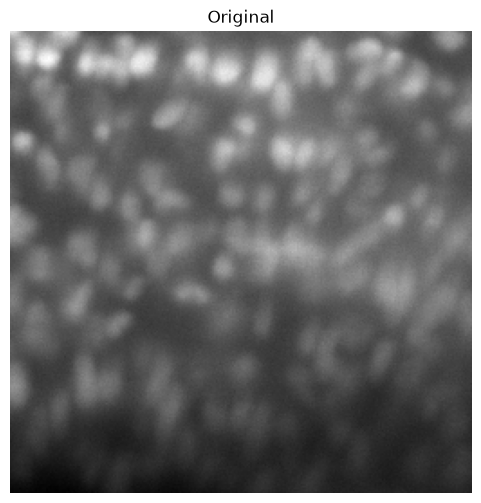

In [9]:
plt.figure(figsize=(6,6))
plt.imshow(volume[z], cmap="gray")
plt.title("Original")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

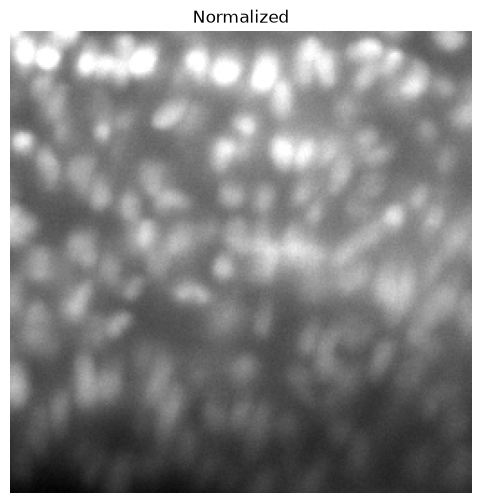

In [10]:
normalized = prepro.normalize_percentile(volume)

plt.figure(figsize=(6,6))
plt.imshow(normalized[z], cmap="gray")
plt.title("Normalized")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

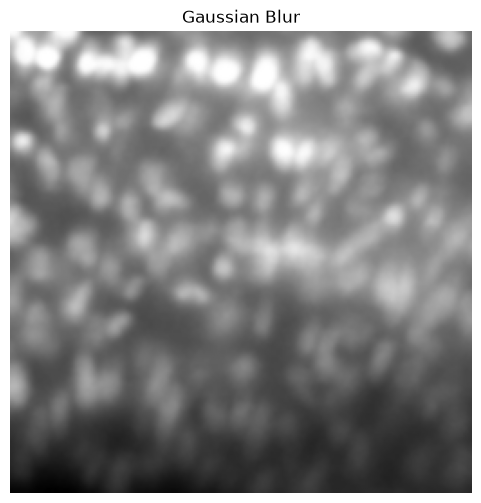

In [18]:
smoothed = prepro.gaussian_blur(normalized)

plt.figure(figsize=(6,6))
plt.imshow(smoothed[z], cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

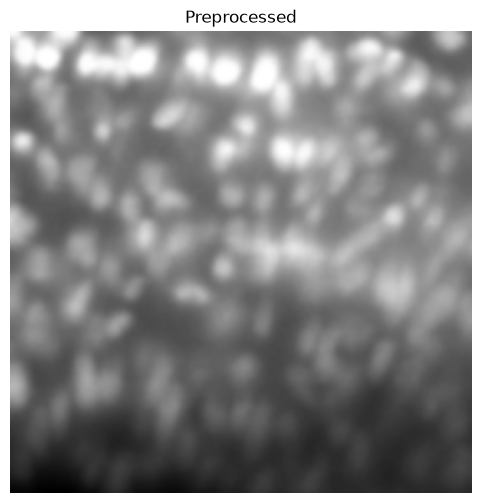

In [19]:
processed = prepro.preprocess(volume)

plt.figure(figsize=(6,6))
plt.imshow(processed[z], cmap="gray")
plt.title("Preprocessed")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

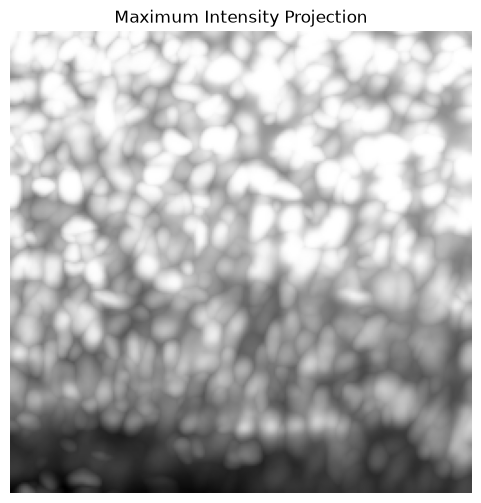

In [9]:
mip = prepro.maximum_intensity_projection(processed)

plt.figure(figsize=(6,6))
plt.imshow(mip, cmap="gray")
plt.title("Maximum Intensity Projection")
plt.axis("off")

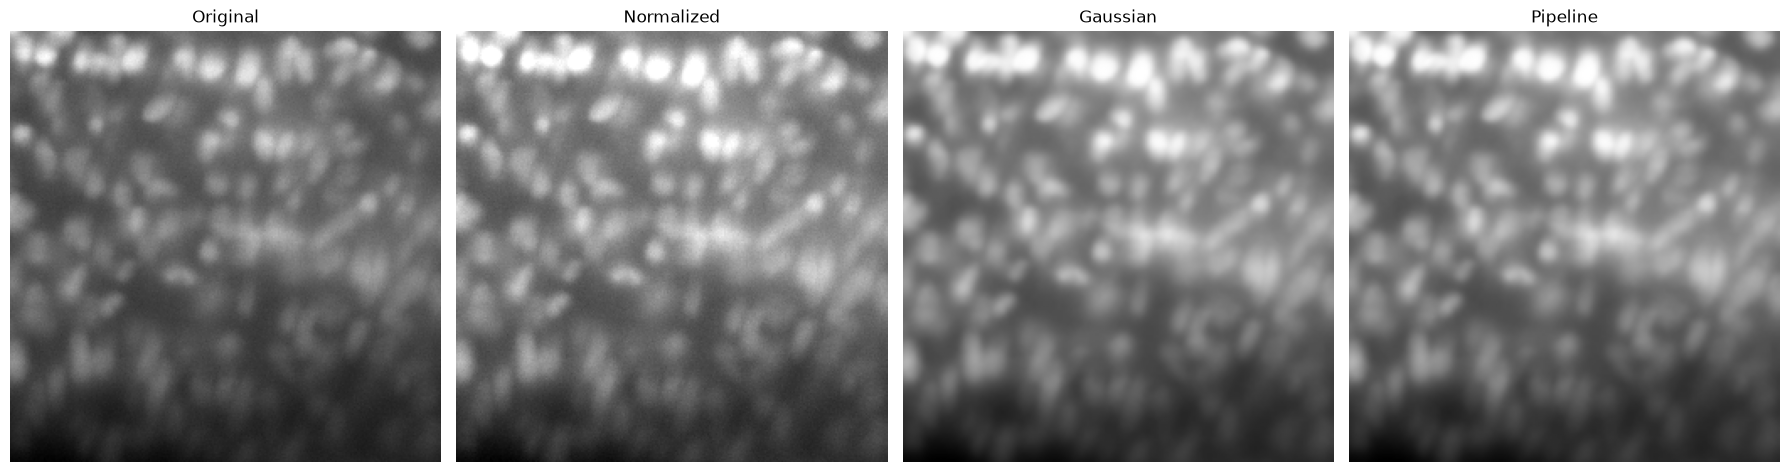

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18,5))

images = [
    volume[z],
    normalized[z],
    smoothed[z],
    processed[z],
]

titles = [
    "Original",
    "Normalized",
    "Gaussian",
    "Pipeline",
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

In [22]:
import src.detector.utils.peak_detection as peak
importlib.reload(peak)

<module 'src.detector.utils.peak_detection' from '/Users/axstormx/Downloads/kaggle-competition/biohub-cell-tracking/src/detector/utils/peak_detection.py'>

In [23]:
config = peak.PeakDetectionConfig()

peaks = peak.detect_local_maxima(
    processed,
    config,
)

print(len(peaks))
peaks[:10]

741


array([[ 25,  22, 116],
       [ 26,  21, 119],
       [ 27,  25, 144],
       [ 28,  20, 116],
       [ 28,  26, 139],
       [ 28,  28, 142],
       [ 29,  20, 119],
       [ 30,  23, 141],
       [ 37,  15, 207],
       [ 46,  74, 254]])

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

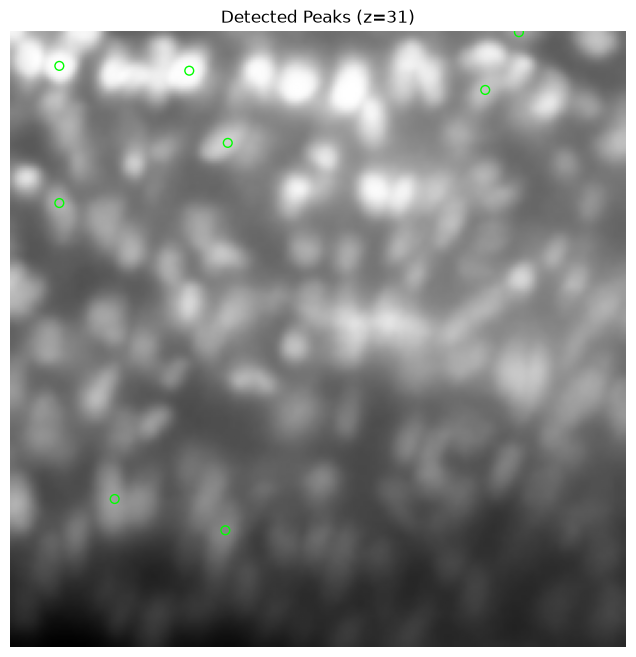

In [16]:
z = 31

slice_peaks = peaks[peaks[:, 0] == z]

plt.figure(figsize=(8, 8))

plt.imshow(processed[z], cmap="gray")

plt.scatter(
    slice_peaks[:, 2],
    slice_peaks[:, 1],
    s=40,
    facecolors="none",
    edgecolors="lime",
)

plt.title(f"Detected Peaks (z={z})")
plt.axis("off")

# Ground Truth vs Detected Peaks

In [17]:
t = 0
z = 31

ground_truth = [
    node
    for node in sample.nodes
    if node.t == t and node.z == z
]

print(f"Ground Truth Cells : {len(ground_truth)}")

Ground Truth Cells : 1


In [18]:
slice_peaks = peaks[
    peaks[:, 0] == z
]

print(f"Detected Peaks : {len(slice_peaks)}")

Detected Peaks : 8


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

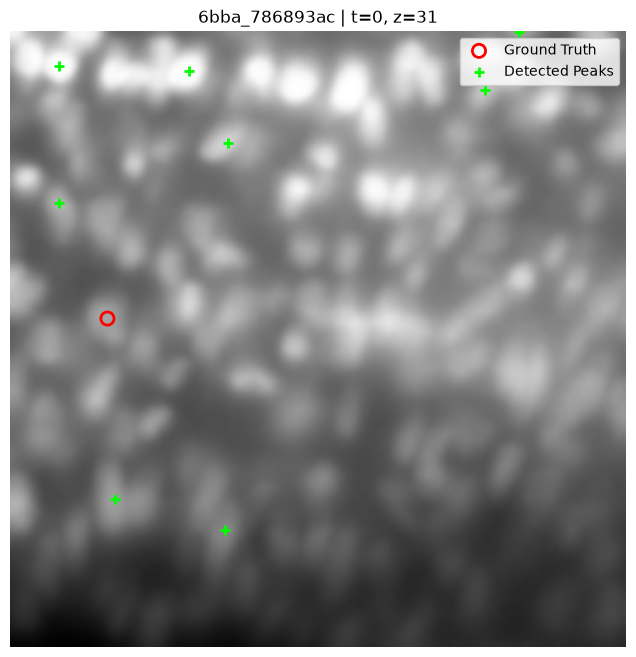

In [19]:
plt.figure(figsize=(8, 8))

plt.imshow(processed[z], cmap="gray")

# Ground Truth
plt.scatter(
    [node.x for node in ground_truth],
    [node.y for node in ground_truth],
    s=90,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Ground Truth",
)

# Detected Peaks
plt.scatter(
    slice_peaks[:, 2],
    slice_peaks[:, 1],
    s=45,
    c="lime",
    marker="+",
    linewidths=2,
    label="Detected Peaks",
)

plt.title(f"{sample.name} | t={t}, z={z}")

plt.legend()

plt.axis("off")

In [20]:
print(f"Ground Truth : {len(ground_truth)}")
print(f"Detected     : {len(slice_peaks)}")

Ground Truth : 1
Detected     : 8


In [21]:
gt_count = sum(
    1
    for node in sample.nodes
    if node.t == t
)

detected_count = len(peaks)

print(f"Ground Truth : {gt_count}")
print(f"Detected     : {detected_count}")

Ground Truth : 18
Detected     : 652


In [24]:
processed = prepro.preprocess(volume)
peak_values = processed[
    peaks[:, 0],
    peaks[:, 1],
    peaks[:, 2],
]

print(f"Minimum: {peak_values.min():.3f}")
print(f"Mean:    {peak_values.mean():.3f}")
print(f"Maximum: {peak_values.max():.3f}")

Minimum: 0.300
Mean:    0.775
Maximum: 1.000


In [25]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    config = peak.PeakDetectionConfig(
        minimum_distance=3,
        threshold_abs=threshold,
    )

    peaks = peak.detect_local_maxima(processed, config)

    print(f"{threshold:.1f} -> {len(peaks)} peaks")

0.3 -> 741 peaks
0.4 -> 700 peaks
0.5 -> 642 peaks
0.6 -> 569 peaks
0.7 -> 481 peaks


## What does this tell us?

Increasing the intensity threshold barely changes the number of detections.

From 0.3 → 0.7, you only removed about 35% of the peaks.

That means:

Most local maxima are genuinely bright.

So the problem is not that we're detecting dim noise.

This is actually a really useful conclusion.

## Therefore, threshold is NOT our bottleneck.

Instead, the detector is finding:

multiple peaks within a single cell,
bright internal structures,
neighboring cells,
and many visible but unannotated cells.

Changing threshold_abs won't solve those issues.

In [27]:
for distance in [3, 5, 7, 9, 11]:
    config = peak.PeakDetectionConfig(
        minimum_distance=distance,
        threshold_abs=0.5,
    )

    peaks = peak.detect_local_maxima(processed, config)

    print(f"{distance:2d} -> {len(peaks)} peaks")

 3 -> 642 peaks
 5 -> 447 peaks
 7 -> 303 peaks
 9 -> 202 peaks
11 -> 137 peaks


# Conclusion

## Findings

- Percentile normalization and Gaussian smoothing produced a clean input volume for classical image processing.
- A 3D local maxima detector successfully identified bright candidate regions.
- Increasing the intensity threshold had only a modest impact on the number of detections.
- Increasing the minimum peak separation substantially reduced duplicate detections but still produced significantly more candidates than annotated cells.

## Conclusion

Classical local maxima detection is a useful baseline and debugging tool, but it is insufficient as a standalone detector for this dataset. Additional filtering or a learned detector will be required to accurately identify annotated cell centers.